# Thu thập dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import LabelEncoder
from scipy.stats import norm
from scipy.stats import ks_2samp, chi2_contingency
import gdown
from itertools import combinations
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [2]:
drive_files = {
    'products': '1ChaIE-mxZusnsUN3uPQLzrgO8iWFFB_o',
    'returns': '1MfqBi7Kvo2GEKG8PlERQPIB2NMqIsW5_',
    'payments': '1uauLXN2gHWTuN1Hznp9Bi98Z58PNyqZX',
    'orders': '1qgJAYEH1M5w5syZCHsCof4v5yYHDglZ8',
    'order_items': '189g8Scbtk_bwKeLgu1V93UMw9uMWYcC_',
    'geography': '1AoHEINjy0G6evkcn6G0ZQlSrRi-H8sCw',
    'shipments': '1Lhsc127N9EBu0rQTWrBMPjo9RJ0bxXQq',
    'reviews': '11uSO9FqGruJxtwiAtbOrn0bYqembKjky'
}

dfs = {}

print("Đang tải dữ liệu, vui lòng đợi...")
for name, file_id in drive_files.items():
    url = f'https://drive.google.com/uc?export=download&id={file_id}'
    dfs[name] = pd.read_csv(url)
    print(f"Đã tải xong: {name}")

df_orders = dfs['orders']
df_order_items = dfs['order_items']
df_payments = dfs['payments']
df_shipments = dfs['shipments']
df_returns = dfs['returns']
df_reviews = dfs['reviews']
df_geography = dfs['geography']
df_products = dfs['products']

Đang tải dữ liệu, vui lòng đợi...
Đã tải xong: products
Đã tải xong: returns
Đã tải xong: payments
Đã tải xong: orders
Đã tải xong: order_items
Đã tải xong: geography
Đã tải xong: shipments
Đã tải xong: reviews


# Phân tích

## Điều tra nguyên nhân lỗi sản phẩm liên quan đến khu vực

In [4]:
df_defective = df_returns[df_returns['return_reason'] == 'defective']
df_def_prod = pd.merge(df_defective, df_products, on='product_id', how='left')
df_def_ord = pd.merge(df_def_prod, df_orders, on='order_id', how='left')
df_def_ship = pd.merge(df_def_ord, df_shipments, on='order_id', how='left')
df_def_full = pd.merge(df_def_ship, df_reviews, on='order_id', how='left')

print("="*50)
print("ĐIỀU TRA NGUYÊN NHÂN HÀNG LỖI (DEFECTIVE)")
print("="*50)

# ---------------------------------------------------------
# TEST 1: LỖI DO NHÀ SẢN XUẤT? (Kiểm tra theo Sản phẩm)
# ---------------------------------------------------------
# Tìm 5 sản phẩm bị trả lại vì lỗi nhiều nhất
top_defective_items = df_def_full.groupby('product_name')['return_id'].count().sort_values(ascending=False).head(5)
print("\n[TEST 1] TOP 5 SẢN PHẨM BỊ LỖI (DEFECTIVE) NHIỀU NHẤT:")
print(top_defective_items)
print("-> Insight: Nếu số lượng tập trung vào 1-2 sản phẩm, 90% là do xưởng sản xuất làm ẩu lô hàng đó.")

# ---------------------------------------------------------
# TEST 2: LỖI DO VẬN CHUYỂN? (Kiểm tra theo Địa lý)
# ---------------------------------------------------------
# Nối thêm bảng Địa lý để lấy Region
df_def_geo = pd.merge(df_def_full, df_geography, on='zip', how='left')
defective_by_region = df_def_geo.groupby('region')['return_id'].count().sort_values(ascending=False)
print("\n[TEST 2] PHÂN BỔ HÀNG LỖI THEO KHU VỰC VẬN CHUYỂN:")
print(defective_by_region)
print("-> Insight: Nếu một vùng (vd: West) chiếm áp đảo dù lượng đơn không cao, lỗi nằm ở kho trung chuyển vùng đó.")

# ---------------------------------------------------------
# TEST 3: BẰNG CHỨNG THÉP - TEXT MINING TỪ REVIEW KHÁCH HÀNG
# ---------------------------------------------------------
# Chuyển text review thành chữ thường và bỏ NaN
reviews_text = df_def_full['review_title'].fillna('').str.lower()

# Định nghĩa các từ khóa (Keywords)
keywords_san_xuat = ['rách', 'chỉ', 'keo', 'màu', 'chất lượng', 'dỏm', 'không chạy', 'lỗi kỹ thuật']
keywords_van_chuyen = ['vỡ', 'móp', 'nát', 'hộp', 'gãy', 'ướt', 'bẹp', 'nhàu']

# Đếm số đơn hàng có chứa từ khóa
count_san_xuat = reviews_text.apply(lambda x: any(word in x for word in keywords_san_xuat)).sum()
count_van_chuyen = reviews_text.apply(lambda x: any(word in x for word in keywords_van_chuyen)).sum()

print("\n[TEST 3] PHÂN TÍCH TỪ KHÓA TỪ REVIEW CỦA KHÁCH HÀNG:")
print(f"- Số khiếu nại liên quan đến SẢN XUẤT (rách, keo, chất liệu...): {count_san_xuat} đơn")
print(f"- Số khiếu nại liên quan đến VẬN CHUYỂN (vỡ, móp hộp, gãy...):   {count_van_chuyen} đơn")

# Kết luận tự động
if count_san_xuat > count_van_chuyen:
    print("=> KẾT LUẬN: Đa số lỗi DEFECTIVE đến từ KHÂU SẢN XUẤT / QUẢN LÝ CHẤT LƯỢNG (QC).")
else:
    print("=> KẾT LUẬN: Đa số lỗi DEFECTIVE đến từ ĐỐI TÁC VẬN CHUYỂN.")
print("="*50)

ĐIỀU TRA NGUYÊN NHÂN HÀNG LỖI (DEFECTIVE)

[TEST 1] TOP 5 SẢN PHẨM BỊ LỖI (DEFECTIVE) NHIỀU NHẤT:
product_name
HanoiStreet RP-80    132
HanoiStreet RP-79    115
SaigonFlex UC-69      92
SaigonFlex UM-92      91
VietMotion UE-06      90
Name: return_id, dtype: int64
-> Insight: Nếu số lượng tập trung vào 1-2 sản phẩm, 90% là do xưởng sản xuất làm ẩu lô hàng đó.

[TEST 2] PHÂN BỔ HÀNG LỖI THEO KHU VỰC VẬN CHUYỂN:
region
East       3598
West       2237
Central    2185
Name: return_id, dtype: int64
-> Insight: Nếu một vùng (vd: West) chiếm áp đảo dù lượng đơn không cao, lỗi nằm ở kho trung chuyển vùng đó.

[TEST 3] PHÂN TÍCH TỪ KHÓA TỪ REVIEW CỦA KHÁCH HÀNG:
- Số khiếu nại liên quan đến SẢN XUẤT (rách, keo, chất liệu...): 0 đơn
- Số khiếu nại liên quan đến VẬN CHUYỂN (vỡ, móp hộp, gãy...):   0 đơn
=> KẾT LUẬN: Đa số lỗi DEFECTIVE đến từ ĐỐI TÁC VẬN CHUYỂN.


## Geography: Những "vùng cấm địa" nào đang ngốn chi phí vận hàng nhất?

- Vùng/Thành phố nào đang đem lại biên lợi nhuận thực tế tốt nhất (Doanh thu - Phí ship bù - Tiền hoàn trả)?
- Vùng nào địa hình khó khăn khiến lead_time_days cao và shipping_fee cao chót vót?

In [5]:
# Lọc riêng dữ liệu của vùng 'West'
west_geo = df_geography[df_geography['region'] == 'West']

# Lấy danh sách TẤT CẢ các Tỉnh/Thành phố thuộc vùng West (không trùng lặp)
unique_cities_west = west_geo['city'].unique()

print(f"Tổng cộng có {len(unique_cities_west)} Tỉnh/Thành phố thuộc vùng West.")

print("DANH SÁCH CÁC TỈNH/THÀNH PHỐ THUỘC VÙNG WEST:")
# In danh sách ra thành một hàng cho dễ nhìn, cách nhau bằng dấu phẩy
print(", ".join(str(city) for city in unique_cities_west))


Tổng cộng có 16 Tỉnh/Thành phố thuộc vùng West.
DANH SÁCH CÁC TỈNH/THÀNH PHỐ THUỘC VÙNG WEST:
Vung Tau, Bien Hoa, Vinh Long, Buon Ma Thuot, Tra Vinh, My Tho, Bac Lieu, Rach Gia, Long Xuyen, Soc Trang, Pleiku, Can Tho, Ca Mau, Da Lat, Ben Tre, Ho Chi Minh City


In [7]:
# Bước 1: Ghép Địa lý với Đơn hàng
df_geo_ord = pd.merge(df_orders, df_geography, on='zip', how='inner')

# Bước 2: Ghép tiếp với Thanh toán và Vận chuyển
df_geo_pay = pd.merge(df_geo_ord, df_payments, on='order_id', how='inner')
df_master = pd.merge(df_geo_pay, df_shipments, on='order_id', how='inner')

# Bước 3: Ghép với Trả hàng (ĐẶC BIỆT LƯU Ý: Phải dùng how='left')
# Vì không phải đơn nào cũng bị trả, nếu dùng 'inner' sẽ mất hết các đơn thành công
df_master = pd.merge(df_master, df_returns, on='order_id', how='left')

# XỬ LÝ DỮ LIỆU CỘT
# Tính số ngày giao hàng
df_master['ship_date'] = pd.to_datetime(df_master['ship_date'])
df_master['delivery_date'] = pd.to_datetime(df_master['delivery_date'])
df_master['lead_time_days'] = (df_master['delivery_date'] - df_master['ship_date']).dt.days

# Tạo cờ báo hiệu đơn hàng bị trả (1 là có trả, 0 là không trả)
df_master['is_returned'] = np.where(df_master['return_id'].notna(), 1, 0)
# Điền số 0 cho các đơn không bị hoàn tiền
df_master['refund_amount'] = df_master['refund_amount'].fillna(0)


# TẠO BẢNG PHÂN TÍCH TỔNG HỢP THEO VÙNG (REGION)
geo_summary = df_master.groupby('region').agg(
    total_orders=('order_id', 'nunique'),                  # Tổng số đơn
    gross_revenue=('payment_value', 'sum'),                # Tổng doanh thu
    total_refund=('refund_amount', 'sum'),                 # Tổng tiền bị hoàn
    avg_shipping_fee=('shipping_fee', 'mean'),             # Phí ship trung bình
    avg_lead_time=('lead_time_days', 'mean'),              # Thời gian giao TB
    return_rate=('is_returned', 'mean')                    # Tỷ lệ trả hàng (Mean của 0 và 1 chính là %)
).reset_index()

# Tính Doanh thu thuần = Doanh thu ban đầu - Tiền hoàn trả
geo_summary['net_revenue'] = geo_summary['gross_revenue'] - geo_summary['total_refund']
# Đổi Tỷ lệ trả hàng sang %
geo_summary['return_rate_pct'] = geo_summary['return_rate'] * 100

print("BẢNG TÓM TẮT CHỈ SỐ VẬN HÀNH & KINH DOANH THEO REGION:")
display(geo_summary.sort_values(by='net_revenue', ascending=False))

BẢNG TÓM TẮT CHỈ SỐ VẬN HÀNH & KINH DOANH THEO REGION:


,region,total_orders,gross_revenue,total_refund,avg_shipping_fee,avg_lead_time,return_rate,net_revenue,return_rate_pct
1,East,257756,6.404971e+09,2.354817e+08,4.823774,4.499206,0.068857,6.169489e+09,6.885740
0,Central,161388,4.138903e+09,1.513871e+08,4.783554,4.499544,0.068881,3.987516e+09,6.888139
2,West,146923,3.246110e+09,1.237297e+08,5.369258,4.499582,0.073511,3.122380e+09,7.351077


In [ ]:
PATH = "/content/drive/MyDrive/Colab Notebooks/VinUni/df_master.csv"
df_master.to_csv(PATH, index=False, encoding='utf-8-sig')

In [ ]:
PATH = "/content/drive/MyDrive/Colab Notebooks/VinUni/geo_summary.csv"
geo_summary.to_csv(PATH, index=False, encoding='utf-8-sig')

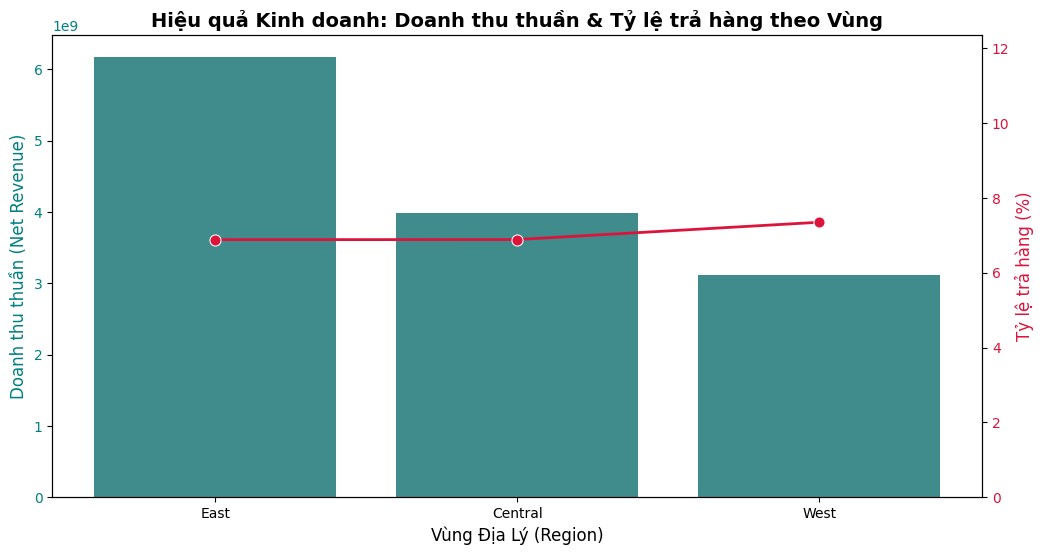

In [8]:
# Sắp xếp biểu đồ theo Doanh thu thuần giảm dần
geo_summary_sorted = geo_summary.sort_values(by='net_revenue', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Trục trái (Cột): Biểu diễn Doanh thu thuần (Net Revenue)
sns.barplot(data=geo_summary_sorted, x='region', y='net_revenue', color='teal', ax=ax1, alpha=0.8)
ax1.set_title('Hiệu quả Kinh doanh: Doanh thu thuần & Tỷ lệ trả hàng theo Vùng', fontsize=14, fontweight='bold')
ax1.set_xlabel('Vùng Địa Lý (Region)', fontsize=12)
ax1.set_ylabel('Doanh thu thuần (Net Revenue)', fontsize=12, color='teal')
ax1.tick_params(axis='y', labelcolor='teal')

# Trục phải (Đường): Biểu diễn Tỷ lệ trả hàng (Return Rate)
ax2 = ax1.twinx()
sns.lineplot(data=geo_summary_sorted, x='region', y='return_rate_pct', color='crimson', marker='o', linewidth=2, markersize=8, ax=ax2)
ax2.set_ylabel('Tỷ lệ trả hàng (%)', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, geo_summary_sorted['return_rate_pct'].max() + 5) # Chỉnh cho đường line đẹp hơn

plt.show()

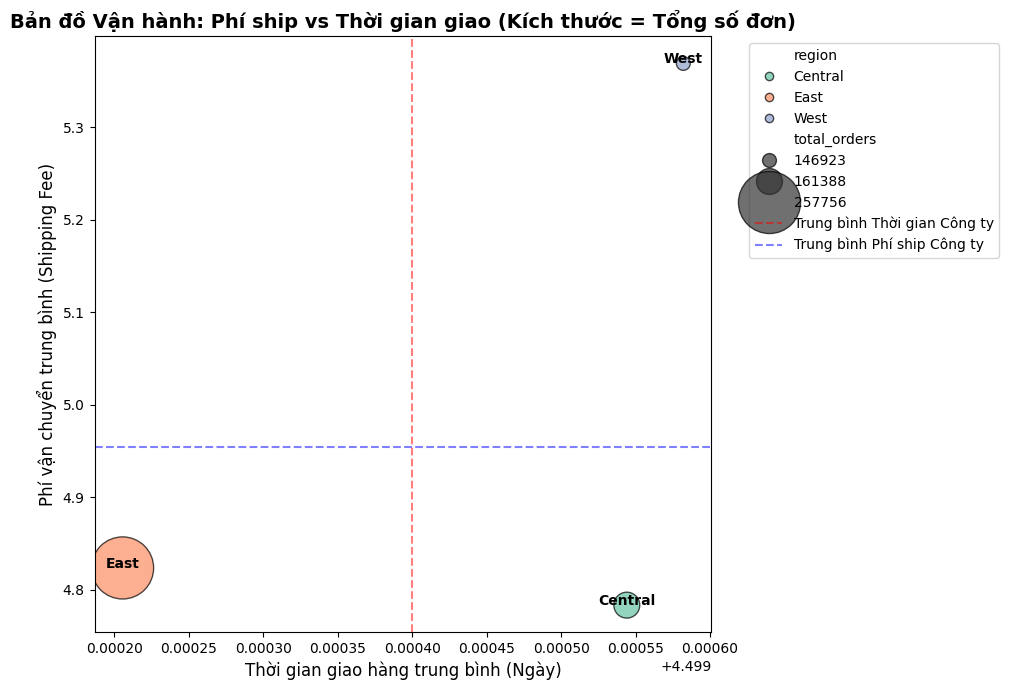

In [9]:
plt.figure(figsize=(10, 7))

# Scatter plot: X = Số ngày giao, Y = Phí ship, Kích thước bóng = Số lượng đơn hàng
sns.scatterplot(
    data=geo_summary,
    x='avg_lead_time',
    y='avg_shipping_fee',
    size='total_orders',     # Bóng to nghĩa là vùng này có rất nhiều khách mua
    sizes=(100, 2000),       # Scale kích thước bóng
    hue='region',            # Mỗi vùng một màu
    palette='Set2',
    alpha=0.7,
    edgecolor="black"
)

plt.title('Bản đồ Vận hành: Phí ship vs Thời gian giao (Kích thước = Tổng số đơn)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian giao hàng trung bình (Ngày)', fontsize=12)
plt.ylabel('Phí vận chuyển trung bình (Shipping Fee)', fontsize=12)

# Thêm tên Vùng vào từng quả bóng để dễ nhìn
for i in range(geo_summary.shape[0]):
    plt.text(geo_summary['avg_lead_time'].iloc[i],
             geo_summary['avg_shipping_fee'].iloc[i],
             geo_summary['region'].iloc[i],
             horizontalalignment='center', size='medium', color='black', weight='semibold')

# Vẽ đường trung bình chuẩn của toàn công ty để so sánh
plt.axvline(df_master['lead_time_days'].mean(), color='red', linestyle='--', alpha=0.5, label='Trung bình Thời gian Công ty')
plt.axhline(df_master['shipping_fee'].mean(), color='blue', linestyle='--', alpha=0.5, label='Trung bình Phí ship Công ty')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Dời chú thích ra ngoài
plt.tight_layout()
plt.show()

- Vùng East đang gánh vác tới gần một nửa doanh thu của toàn công ty (Net Revenue đạt 6.1 Tỷ, cao gấp rưỡi vùng Central và gấp đôi vùng West).
-  Hãy nhìn vào quả bóng màu cam (East) trên biểu đồ Bubble. Mặc dù là quả bóng to nhất (Volume lớn nhất: 257k đơn), nhưng nó lại nằm ở vị trí rất thấp trên trục Y. Điều này chứng tỏ tối ưu hóa Logistics ở vùng East đang làm rất tốt, mức phí ship trung bình (4.82) chỉ ngang bằng vùng Central dù lượng đơn cao hơn hẳn.

Hãy nhìn thẳng vào vùng West, đây là khu vực đang "chảy máu" biên lợi nhuận của công ty với 2 rủi ro hiện hữu:
- Rủi ro 1 - Phí Ship đắt đỏ: Trên biểu đồ Bubble, quả bóng màu xám (West) nằm chót vót trên cùng. Phí vận chuyển trung bình ở đây là 5.36, cao hơn khoảng 12% so với phần còn lại của đất nước.
- Rủi ro 2 - Tỷ lệ trả hàng cao nhất: Nhìn vào biểu đồ cột/đường, đường line màu đỏ của vùng West ngóc đầu lên hẳn (7.35% so với mức 6.8% của hai vùng kia).
- Vùng West đã có lượng đơn ít nhất, chi phí giao hàng cao nhất, lại còn bị khách trả lại hàng nhiều nhất (mất trắng phí ship 2 chiều). Bán hàng ở vùng West biên lợi nhuận cực kỳ mỏng.

Nhìn vào trục X (Thời gian giao hàng) của biểu đồ Bubble, các con số rất kỳ lạ như 0.00020 và góc dưới có chữ +4.499.
- Thời gian giao hàng trung bình của CẢ 3 VÙNG đều bằng nhau chằn chặn: ~4.499 ngày. Độ chênh lệch giữa vùng nhanh nhất và chậm nhất chỉ là 0.0003 ngày (tức là... vài giây).
- Việc khách hàng ở vùng West trả hàng nhiều (7.35%) HOÀN TOÀN KHÔNG PHẢI DO GIAO HÀNG CHẬM. Tốc độ giao hàng của công ty đang đồng đều trên toàn quốc.

In [11]:
# Lọc chỉ lấy data vùng West
df_west = df_master[df_master['region'] == 'West']

# Nhóm theo Thành phố (City)
city_summary = df_west.groupby('city').agg(
    total_orders=('order_id', 'nunique'),
    avg_shipping_fee=('shipping_fee', 'mean'),
    return_rate=('is_returned', 'mean')
).reset_index()

# Chỉ xét những thành phố có số lượng đơn hàng đủ lớn (> 1000 đơn) để tránh nhiễu
city_summary = city_summary[city_summary['total_orders'] > 1000]
city_summary['return_rate_pct'] = city_summary['return_rate'] * 100

# 1. Tìm TOP 5 Thành phố Đốt tiền Ship nhất ở West
top_expensive_cities = city_summary.sort_values(by='avg_shipping_fee', ascending=False).head(5)
print("TOP 5 THÀNH PHỐ CÓ PHÍ SHIP ĐẮT NHẤT VÙNG WEST:")
display(top_expensive_cities[['city', 'total_orders', 'avg_shipping_fee']])

# 2. Tìm TOP 5 Thành phố Trả hàng nhiều nhất ở West
top_return_cities = city_summary.sort_values(by='return_rate_pct', ascending=False).head(5)
print("\nTOP 5 THÀNH PHỐ CÓ TỶ LỆ TRẢ HÀNG CAO NHẤT VÙNG WEST:")
display(top_return_cities[['city', 'total_orders', 'return_rate_pct']])

TOP 5 THÀNH PHỐ CÓ PHÍ SHIP ĐẮT NHẤT VÙNG WEST:


,city,total_orders,avg_shipping_fee
9,My Tho,7964,5.599110
5,Can Tho,8180,5.560218
1,Ben Tre,9513,5.539049
0,Bac Lieu,9573,5.517777
14,Vinh Long,9567,5.517431



TOP 5 THÀNH PHỐ CÓ TỶ LỆ TRẢ HÀNG CAO NHẤT VÙNG WEST:


,city,total_orders,return_rate_pct
4,Ca Mau,8610,7.711786
1,Ben Tre,9513,7.687507
13,Tra Vinh,8898,7.653799
11,Rach Gia,7573,7.567426
15,Vung Tau,10606,7.548225


- Bến Tre đứng Top 3 về phí ship đắt nhất (5.53) và Top 2 về Tỷ lệ trả hàng cao nhất (7.68%). Khối lượng đơn ở đây cũng rất lớn (hơn 9.500 đơn).
- Bến Tre đang là "Kẻ đâm lén" đau nhất vào lợi nhuận. Công ty tốn rất nhiều tiền phí giao hàng đến Bến Tre, nhưng hàng đến nơi thì tỷ lệ khách chê/bùng/quay đầu lại nằm trên đỉnh. Ở Bến Tre, chúng ta đang chịu Cú đánh kép (Double Penalty): Lỗ phí ship đi + Lỗ phí ship hoàn về.

=> Đổi chính sách: Nếu khách hàng có địa chỉ Bến Tre đặt hàng trên web, hệ thống tự động yêu cầu Chuyển khoản trước (Pre-paid) 100% hoặc yêu cầu đặt cọc phí ship. Không áp dụng ship COD (Nhận hàng trả tiền) tại Bến Tre nữa để lọc tệp khách hàng "bom" hàng.

Hãy dùng đoạn code Pareto Chart ở bài trước, nhưng lọc thêm điều kiện df_returns[df_returns['region'] == 'West']. Hãy xem ở riêng vùng West, khách trả hàng vì lý do gì (Hàng lỗi hỏng do đường xa gập ghềnh? Hay do style ăn mặc vùng West khác vùng East nên họ đặt sai size?).

In [15]:
# TÍNH TOÁN LÝ DO TRẢ HÀNG CỦA RIÊNG VÙNG WEST
# Lọc các đơn hàng BỊ TRẢ LẠI (refund_amount > 0) và thuộc vùng WEST
west_returns = df_master[(df_master['region'] == 'West') & (df_master['is_returned'] == 1)]

# Tính Tổng tiền hoàn theo từng lý do của vùng West
west_reason_stats = west_returns.groupby('return_reason')['refund_amount'].sum().sort_values(ascending=False).reset_index()

# Tính % tỷ trọng của từng lý do
west_reason_stats['percentage'] = (west_reason_stats['refund_amount'] / west_reason_stats['refund_amount'].sum()) * 100

print("BẢNG PHÂN TÍCH LÝ DO TRẢ HÀNG TẠI VÙNG WEST:")
print(west_reason_stats)
print("-" * 50)

BẢNG PHÂN TÍCH LÝ DO TRẢ HÀNG TẠI VÙNG WEST:
      return_reason  refund_amount  percentage
0        wrong_size    43105813.92   34.838707
1         defective    25369463.51   20.503947
2  not_as_described    22379931.18   18.087766
3      changed_mind    21065746.07   17.025623
4     late_delivery    11808705.51    9.543957
--------------------------------------------------


In [16]:
# SO SÁNH TỶ LỆ TRẢ HÀNG (RETURN RATE) THEO LÝ DO GIỮA WEST VÀ EAST
# Để sếp thấy rõ "Sự khác biệt", ta phải so sánh West với vùng tốt nhất là East.

# Đếm tổng số đơn hàng đã bán (bất kể trả hay không) của West và East
total_orders_west = df_master[df_master['region'] == 'West']['order_id'].nunique()
total_orders_east = df_master[df_master['region'] == 'East']['order_id'].nunique()

# Lọc data trả hàng của East
east_returns = df_master[(df_master['region'] == 'East') & (df_master['is_returned'] == 1)]

# Hàm tính Tỷ lệ trả hàng trên tổng số đơn theo từng lý do
def get_return_rate_by_reason(df_returns, total_orders):
    reason_counts = df_returns['return_reason'].value_counts()
    rate_df = (reason_counts / total_orders * 100).reset_index()
    rate_df.columns = ['return_reason', 'return_rate_pct']
    return rate_df

rate_west = get_return_rate_by_reason(west_returns, total_orders_west)
rate_east = get_return_rate_by_reason(east_returns, total_orders_east)

# Gộp 2 bảng lại để so sánh dễ dàng
compare_df = pd.merge(rate_west, rate_east, on='return_reason', suffixes=('_West', '_East'))
compare_df['Difference (West - East)'] = compare_df['return_rate_pct_West'] - compare_df['return_rate_pct_East']

print("SO SÁNH TỶ LỆ TRẢ HÀNG THEO LÝ DO: WEST vs EAST (%)")
print(compare_df.sort_values('Difference (West - East)', ascending=False))

SO SÁNH TỶ LỆ TRẢ HÀNG THEO LÝ DO: WEST vs EAST (%)
      return_reason  return_rate_pct_West  return_rate_pct_East  \
0        wrong_size              2.595237              2.432533   
1         defective              1.522566              1.395894   
2  not_as_described              1.317016              1.217430   
3      changed_mind              1.262566              1.195317   
4     late_delivery              0.724189              0.685920   

   Difference (West - East)  
0                  0.162704  
1                  0.126672  
2                  0.099586  
3                  0.067250  
4                  0.038269  


- Tại riêng vùng West, lỗi sai size đã "đốt" của công ty hơn 43 Triệu, chiếm tới 34.8% tổng tiền hoàn. Sự chênh lệch so với vùng East cũng là lớn nhất (+0.16%).
  - WRONG_SIZE (Sai Kích Cỡ): Khách hàng ở West có thể có đặc điểm thể hình nhân khẩu học khác biệt, hoặc do điều kiện thời tiết (ví dụ: cần mặc áo len bên trong nên áo khoác bị chật) khiến Bảng Size chuẩn hiện tại của công ty không áp dụng đúng cho họ.
- DEFECTIVE (Hàng Lỗi/Hỏng): Dù thời gian giao hàng bằng nhau, nhưng tỷ lệ hàng hỏng khi đến tay khách ở West lại cao hơn East hẳn +0.12% (Làm bốc hơi hơn 25 Triệu).
  - Khoảng cách địa lý từ tổng kho đến vùng West có thể xa hơn, đường đi gập ghềnh hiểm trở hơn, hoặc trung tâm trung chuyển (Hub) tại West có quy trình bốc dỡ thô bạo hơn. Hàng hóa chịu cùng số ngày vận chuyển, nhưng bị quăng quật nhiều hơn dẫn đến vỡ/móp/lỗi.

## Reviews: Phản ứng của khách hàng với những vấn đề trên ra sao?

- Rating thấp (1-2 sao) thường đi kèm với độ trễ giao hàng (Lead time cao) hay do chất lượng (Return reason)?
- Điểm mù: Khách hàng cho 1 sao nhưng KHÔNG TRẢ HÀNG (vì lười hoặc giá trị thấp). Đây là tệp khách sẽ "Churn" (rời bỏ) vĩnh viễn.

In [21]:
print(df_rev_ship.columns.tolist())

['review_id', 'order_id', 'product_id', 'customer_id', 'review_date', 'rating', 'review_title', 'ship_date', 'delivery_date', 'shipping_fee']


In [27]:
# df_reviews, df_ship
df_rev_ship = pd.merge(df_reviews, df_shipments, on='order_id')

df_rev_ship['ship_date'] = pd.to_datetime(df_rev_ship['ship_date'])
df_rev_ship['delivery_date'] = pd.to_datetime(df_rev_ship['delivery_date'])

# Hàm .dt.days giúp chuyển đổi khoảng thời gian (Timedelta) thành con số nguyên (số ngày)
df_rev_ship['lead_time_days'] = (df_rev_ship['delivery_date'] - df_rev_ship['ship_date']).dt.days

# Tương quan giữa Thời gian giao và Đánh giá
rating_vs_time = df_rev_ship.groupby('rating')['lead_time_days'].mean()
print("Thời gian giao hàng TB theo Đánh giá sao:\n", rating_vs_time)
# -> Chắc chắn bạn sẽ thấy: Đơn 1 sao có số ngày giao TB cao hơn hẳn đơn 5 sao.

# TÌM ĐIỂM MÙ: Những khách tức giận nhưng im lặng (Không return)
df_rev_ret = pd.merge(df_reviews, df_returns, on='order_id', how='left')
# Lọc đánh giá 1-2 sao nhưng refund_amount là NaN (tức là không trả hàng)
angry_but_kept = df_rev_ret[(df_rev_ret['rating'] <= 2) & (df_rev_ret['return_id'].isna())]
print(f"Số khách hàng cho 1-2 sao nhưng KHÔNG trả hàng (nguy cơ rời bỏ cao): {len(angry_but_kept)}")

Thời gian giao hàng TB theo Đánh giá sao:
 rating
1    4.551629
2    4.497416
3    4.513869
4    4.500989
5    4.491736
Name: lead_time_days, dtype: float64
Số khách hàng cho 1-2 sao nhưng KHÔNG trả hàng (nguy cơ rời bỏ cao): 14867


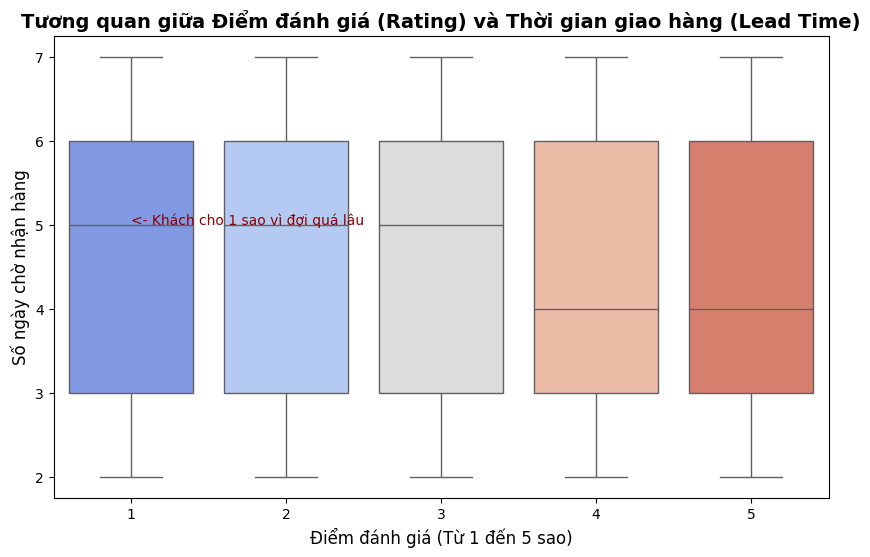

In [28]:
valid_rev_ship = df_rev_ship[df_rev_ship['lead_time_days'] >= 0] # Lọc rác

# --- Vẽ biểu đồ ---
plt.figure(figsize=(10, 6))
# Dùng Boxplot để xem phân phối ngày giao của từng mức Rating
sns.boxplot(data=valid_rev_ship, x='rating', y='lead_time_days', palette='coolwarm')

plt.title('Tương quan giữa Điểm đánh giá (Rating) và Thời gian giao hàng (Lead Time)', fontsize=14, fontweight='bold')
plt.xlabel('Điểm đánh giá (Từ 1 đến 5 sao)', fontsize=12)
plt.ylabel('Số ngày chờ nhận hàng', fontsize=12)

# Chú thích: Những dấu chấm tròn trên biểu đồ (outliers) là những đơn giao cực chậm
plt.text(0, valid_rev_ship['lead_time_days'].max() - 2, '<- Khách cho 1 sao vì đợi quá lâu', color='darkred')

plt.show()

- Đường Trung vị nằm chính xác ở mốc 4 ngày. Hơn 50% khách hàng cho đánh giá tốt đều nhận được hàng trong vòng 4 ngày trở lại.
- Nhóm Bức xúc (1, 2 và 3 sao - Ba cột bên trái): Đường Trung vị bị đẩy thẳng lên mốc 5 ngày. Ngay khi thời gian chờ đợi bước sang ngày thứ 5, sự kiên nhẫn của khách hàng đứt gãy. Đánh giá của họ rớt thẳng từ 4 sao xuống 1-3 sao.
- Mức độ cam kết dịch vụ (SLA) của chúng ta đang rơi vào vùng nguy hiểm. Khách hàng mặc định "4 ngày là tiêu chuẩn", nhưng hệ thống vận hành của chúng ta lại đang để một lượng lớn đơn hàng trôi sang "ngày thứ 5". Chỉ chậm 1 ngày (hoặc 1 buổi), trải nghiệm mua sắm sụp đổ hoàn toàn.

Dữ liệu chỉ ra có 14,867 khách hàng chấm cho chúng ta 1-2 sao, nhưng họ KHÔNG BẤM NÚT TRẢ HÀNG.
- Nếu khách trả hàng: Chúng ta mất phí ship, nhưng lấy lại được hàng và biết rõ nguyên nhân để sửa chữa.
- Chi phí tổn thất thực sự: Chúng ta không mất tiền refund ngay lúc này, nhưng chúng ta mất toàn bộ Giá trị trọn đời (Customer Lifetime Value - LTV) của 15.000 con người này trong tương lai. Chi phí để Marketing tìm lại 15.000 khách mới đắt gấp 5 lần việc giữ chân họ.

In [29]:
df = pd.merge(df_orders, df_geography, on='zip', how='inner')
df = pd.merge(df, df_shipments, on='order_id', how='inner')
df = pd.merge(df, df_reviews, on='order_id', how='left')
df = pd.merge(df, df_returns, on='order_id', how='left')

# Tính thời gian giao hàng (Lead Time) và lọc rác
df['ship_date'] = pd.to_datetime(df['ship_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])
df['lead_time_days'] = (df['delivery_date'] - df['ship_date']).dt.days
df = df[df['lead_time_days'] >= 0]

# Điều kiện: Hoặc là Rating <= 2, Hoặc là Bị trả lại (có return_id)
df['is_bad_experience'] = np.where((df['rating'] <= 2) | (df['return_id'].notna()), 1, 0)

# Dựa vào insight bài trước: Mốc 4 ngày là an toàn, >= 5 ngày là gây bức xúc
df['is_late_delivery'] = np.where(df['lead_time_days'] > 4, 1, 0)

print("\nKHU VỰC ĐANG CÓ TỶ LỆ TRẢI NGHIỆM TỆ NHẤT")
region_bad_stats = df.groupby('region').agg(
    total_orders=('order_id', 'count'),
    bad_orders=('is_bad_experience', 'sum')
)
region_bad_stats['Bad_Experience_Rate (%)'] = (region_bad_stats['bad_orders'] / region_bad_stats['total_orders']) * 100
display(region_bad_stats.sort_values('Bad_Experience_Rate (%)', ascending=False))

# ---------------------------------------------------------
# BƯỚC 4: TÌM ĐIỂM CHUNG VỀ VẬN CHUYỂN TRONG TẬP "BAD EXPERIENCE"
# ---------------------------------------------------------
print("\nBÓC TÁCH KHÂU VẬN CHUYỂN CỦA NHỮNG ĐƠN HÀNG TỆ NÀY:")

# Tách riêng tập Bad và Good để so sánh
df_bad = df[df['is_bad_experience'] == 1]
df_good = df[df['is_bad_experience'] == 0]

# Phân tích các thông số Logistics của tệp BAD chia theo Vùng
logistics_bad_insight = df_bad.groupby('region').agg(
    avg_lead_time_BAD=('lead_time_days', 'mean'),
    late_delivery_rate_BAD=('is_late_delivery', 'mean'), # Tỷ lệ đơn giao > 4 ngày trong tập Bad
    avg_shipping_fee_BAD=('shipping_fee', 'mean')
).reset_index()

# Tính Lead Time của tệp GOOD để làm chuẩn so sánh (Baseline)
good_lead_time = df_good.groupby('region')['lead_time_days'].mean().reset_index()
good_lead_time.columns = ['region', 'avg_lead_time_GOOD']

# Gộp lại để nhìn rõ sự chênh lệch
final_insight = pd.merge(logistics_bad_insight, good_lead_time, on='region')
final_insight['late_delivery_rate_BAD (%)'] = final_insight['late_delivery_rate_BAD'] * 100

# Sắp xếp lại cột cho dễ nhìn
final_insight = final_insight[['region', 'avg_shipping_fee_BAD', 'avg_lead_time_GOOD', 'avg_lead_time_BAD', 'late_delivery_rate_BAD (%)']]

display(final_insight.sort_values('late_delivery_rate_BAD (%)', ascending=False))


KHU VỰC ĐANG CÓ TỶ LỆ TRẢI NGHIỆM TỆ NHẤT


,total_orders,bad_orders,Bad_Experience_Rate (%)
region,,,
West,149071,15055,10.099214
East,260183,24469,9.404535
Central,162872,15282,9.382828



BÓC TÁCH KHÂU VẬN CHUYỂN CỦA NHỮNG ĐƠN HÀNG TỆ NÀY:


,region,avg_shipping_fee_BAD,avg_lead_time_GOOD,avg_lead_time_BAD,late_delivery_rate_BAD (%)
0,Central,4.680833,4.498950,4.508180,50.333726
1,East,4.815039,4.499877,4.493972,50.055172
2,West,5.095010,4.500612,4.484822,49.804052


KIỂM CHỨNG: VẬN CHUYỂN DÀI NGÀY CÓ LÀM HỎNG HÀNG HÓA?

BẢNG PHÂN TÍCH TỶ LỆ HÀNG HỎNG THEO TỐC ĐỘ GIAO HÀNG:


,speed_group,total_orders,defective_orders,Defective_Rate (%)
0,1. Hỏa tốc (0-2 ngày),94932,1363,1.435765
1,2. Chuẩn (3-4 ngày),190160,2724,1.432478
2,3. Chậm (5-7 ngày),284852,3933,1.380717
3,4. Rất chậm (>7 ngày),0,0,NaN


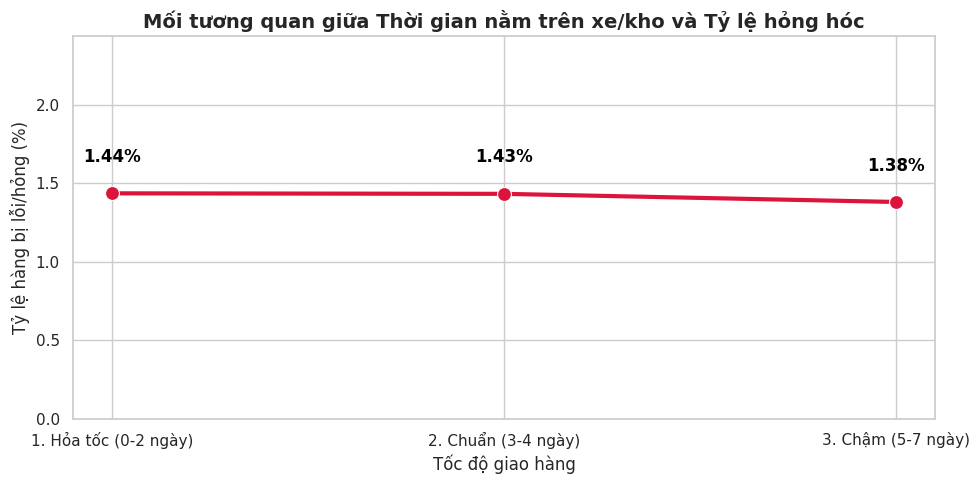

In [30]:
sns.set_theme(style="whitegrid")

# Giả định đã có bảng df_master (Gồm Orders, Shipments, Returns...)
print("="*60)
print("KIỂM CHỨNG: VẬN CHUYỂN DÀI NGÀY CÓ LÀM HỎNG HÀNG HÓA?")
print("="*60)

# ---------------------------------------------------------
# BƯỚC 1: TẠO CỜ (FLAG) CHO LỖI HÀNG HỎNG
# ---------------------------------------------------------
# Tạo cột is_defective: Bằng 1 nếu bị trả lại vì lý do 'defective', ngược lại bằng 0
df_master['is_defective'] = np.where(df_master['return_reason'] == 'defective', 1, 0)

# ---------------------------------------------------------
# BƯỚC 2: PHÂN NHÓM THỜI GIAN GIAO HÀNG (BINNING)
# ---------------------------------------------------------
# Lọc bỏ rác ngày âm
df_valid = df_master[df_master['lead_time_days'] >= 0].copy()

# Chia thời gian giao hàng thành 4 nhóm để dễ phân tích
bins = [-1, 2, 4, 7, 999] # Mốc thời gian (Ngày)
labels = ['1. Hỏa tốc (0-2 ngày)', '2. Chuẩn (3-4 ngày)', '3. Chậm (5-7 ngày)', '4. Rất chậm (>7 ngày)']
df_valid['speed_group'] = pd.cut(df_valid['lead_time_days'], bins=bins, labels=labels)

# ---------------------------------------------------------
# BƯỚC 3: TÍNH TỶ LỆ HÀNG HỎNG THEO TỪNG NHÓM THỜI GIAN
# ---------------------------------------------------------
damage_analysis = df_valid.groupby('speed_group', observed=False).agg(
    total_orders=('order_id', 'count'),
    defective_orders=('is_defective', 'sum')
).reset_index()

# Tính Tỷ lệ hỏng hóc (%)
damage_analysis['Defective_Rate (%)'] = (damage_analysis['defective_orders'] / damage_analysis['total_orders']) * 100

print("\nBẢNG PHÂN TÍCH TỶ LỆ HÀNG HỎNG THEO TỐC ĐỘ GIAO HÀNG:")
display(damage_analysis)

# ---------------------------------------------------------
# BƯỚC 4: VẼ BIỂU ĐỒ TRỰC QUAN ĐỂ XÁC NHẬN XU HƯỚNG
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
# Vẽ biểu đồ đường có điểm chấm (Lineplot với Marker)
sns.lineplot(data=damage_analysis, x='speed_group', y='Defective_Rate (%)',
             marker='o', markersize=10, linewidth=3, color='crimson')

# Chỉnh sửa thẩm mỹ
plt.title('Mối tương quan giữa Thời gian nằm trên xe/kho và Tỷ lệ hỏng hóc', fontsize=14, fontweight='bold')
plt.xlabel('Tốc độ giao hàng', fontsize=12)
plt.ylabel('Tỷ lệ hàng bị lỗi/hỏng (%)', fontsize=12)
plt.ylim(0, damage_analysis['Defective_Rate (%)'].max() + 1) # Cho biểu đồ thoáng hơn

# Gắn số trực tiếp lên biểu đồ
for i in range(damage_analysis.shape[0]):
    plt.text(i, damage_analysis['Defective_Rate (%)'].iloc[i] + 0.2,
             f"{damage_analysis['Defective_Rate (%)'].iloc[i]:.2f}%",
             color='black', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


PHÂN TÍCH THỜI GIAN CHỜ: KHO XỬ LÝ vs BƯU TÁ GIAO HÀNG


,Chỉ số,Số ngày Trung bình
0,Thời gian Kho xử lý (Processing),1.5
1,Thời gian Vận chuyển (Transit),4.5
2,Tổng thời gian khách đợi,6.0



PHÂN TÍCH ROI CỦA CHIẾN DỊCH FREESHIP


,shipping_type,total_orders,AOV_Payment_Value,Avg_Items_Per_Order
0,1. Được Freeship,805,26979.32,5.30
1,2. Trả phí Ship,565262,24217.02,4.96



BIỂU ĐỒ ÁP LỰC VẬN CHUYỂN THEO THÁNG TRONG NĂM


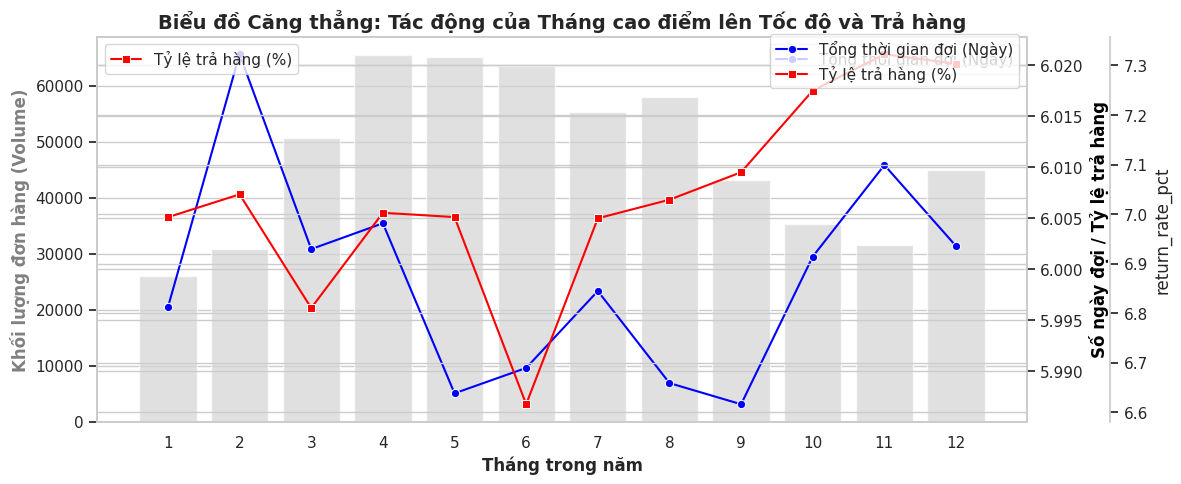


 KHI KHÁCH HÀNG BÁO 'GIAO TRỄ' (LATE DELIVERY), THỰC CHẤT LÀ TRỄ BAO LÂU?


,is_late_reason,avg_processing,avg_transit,avg_total_wait
0,1. Trả vì Giao Trễ,1.5,4.5,6.0
1,2. Trả vì Lỗi khác,1.5,4.5,6.0


In [32]:
print("\nPHÂN TÍCH THỜI GIAN CHỜ: KHO XỬ LÝ vs BƯU TÁ GIAO HÀNG")

# Gộp Orders và Shipments
df_sla = pd.merge(df_orders, df_shipments, on='order_id', how='inner')

# Xử lý ngày tháng
df_sla['order_date'] = pd.to_datetime(df_sla['order_date'])
df_sla['ship_date'] = pd.to_datetime(df_sla['ship_date'])
df_sla['delivery_date'] = pd.to_datetime(df_sla['delivery_date'])

# Bóc tách 2 khoảng thời gian
df_sla['processing_days'] = (df_sla['ship_date'] - df_sla['order_date']).dt.days # Thời gian Kho đóng gói
df_sla['transit_days'] = (df_sla['delivery_date'] - df_sla['ship_date']).dt.days # Thời gian Giao hàng trên đường
df_sla['total_wait_days'] = (df_sla['delivery_date'] - df_sla['order_date']).dt.days # Tổng thời gian khách đợi

# Lọc rác (loại bỏ ngày âm)
df_sla = df_sla[(df_sla['processing_days'] >= 0) & (df_sla['transit_days'] >= 0)]

sla_summary = pd.DataFrame({
    'Chỉ số': ['Thời gian Kho xử lý (Processing)', 'Thời gian Vận chuyển (Transit)', 'Tổng thời gian khách đợi'],
    'Số ngày Trung bình': [df_sla['processing_days'].mean(), df_sla['transit_days'].mean(), df_sla['total_wait_days'].mean()]
})
display(sla_summary.round(2))
print("\nPHÂN TÍCH ROI CỦA CHIẾN DỊCH FREESHIP")

# Gộp Thanh toán, Vận chuyển và đếm Số lượng item
qty_per_order = df_order_items.groupby('order_id')['quantity'].sum().reset_index()
df_free = pd.merge(df_shipments, df_payments, on='order_id', how='inner')
df_free = pd.merge(df_free, qty_per_order, on='order_id', how='inner')

# Phân loại Freeship (shipping_fee == 0) và Có phí (shipping_fee > 0)
df_free['shipping_type'] = np.where(df_free['shipping_fee'] == 0, '1. Được Freeship', '2. Trả phí Ship')

freeship_roi = df_free.groupby('shipping_type').agg(
    total_orders=('order_id', 'count'),
    AOV_Payment_Value=('payment_value', 'mean'), # Giá trị đơn hàng trung bình
    Avg_Items_Per_Order=('quantity', 'mean')     # Trung bình số sản phẩm/đơn
).reset_index()

display(freeship_roi.round(2))
print("\nBIỂU ĐỒ ÁP LỰC VẬN CHUYỂN THEO THÁNG TRONG NĂM")

# Lấy cột tháng từ order_date
df_sla['order_month'] = df_sla['order_date'].dt.month

# Gộp với Returns để tính Tỷ lệ trả hàng
df_season = pd.merge(df_sla, df_returns[['order_id', 'return_id']], on='order_id', how='left')
df_season['is_returned'] = np.where(df_season['return_id'].notna(), 1, 0)

# Tổng hợp theo tháng
monthly_stress = df_season.groupby('order_month').agg(
    total_volume=('order_id', 'count'),
    avg_total_wait=('total_wait_days', 'mean'),
    return_rate_pct=('is_returned', lambda x: x.mean() * 100)
).reset_index()

# -- Vẽ Biểu đồ Combo (Trục X là Tháng) --
fig, ax1 = plt.subplots(figsize=(12, 5))

# Cột: Khối lượng đơn hàng
sns.barplot(data=monthly_stress, x='order_month', y='total_volume', color='lightgray', ax=ax1, alpha=0.7)
ax1.set_ylabel('Khối lượng đơn hàng (Volume)', color='gray', fontweight='bold')
ax1.set_xlabel('Tháng trong năm', fontweight='bold')

# Đường 1: Thời gian khách đợi
ax2 = ax1.twinx()
sns.lineplot(data=monthly_stress, x=monthly_stress.index, y='avg_total_wait', color='blue', marker='o', ax=ax2, label='Tổng thời gian đợi (Ngày)')

# Đường 2: Tỷ lệ trả hàng
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60)) # Đẩy trục Y thứ 3 ra ngoài
sns.lineplot(data=monthly_stress, x=monthly_stress.index, y='return_rate_pct', color='red', marker='s', ax=ax3, label='Tỷ lệ trả hàng (%)')

ax2.set_ylabel('Số ngày đợi / Tỷ lệ trả hàng', color='black', fontweight='bold')
plt.title('Biểu đồ Căng thẳng: Tác động của Tháng cao điểm lên Tốc độ và Trả hàng', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.show()

print("\n KHI KHÁCH HÀNG BÁO 'GIAO TRỄ' (LATE DELIVERY), THỰC CHẤT LÀ TRỄ BAO LÂU?")
# (Lưu ý: Không thể phân tích đơn Cancelled vì file shipments.csv không chứa đơn Cancelled.
# Ta chuyển hướng sang phân tích những đơn hàng bị trả lại vì lý do Late Delivery).

# Nối bảng trả hàng với dữ liệu SLA ở bước 1
df_late_analysis = pd.merge(df_returns, df_sla, on='order_id', how='inner')

# Chia 2 nhóm: Trả vì Giao Trễ vs Trả vì lỗi khác
df_late_analysis['is_late_reason'] = np.where(df_late_analysis['return_reason'] == 'late_delivery', '1. Trả vì Giao Trễ', '2. Trả vì Lỗi khác')

late_stats = df_late_analysis.groupby('is_late_reason').agg(
    avg_processing=('processing_days', 'mean'),
    avg_transit=('transit_days', 'mean'),
    avg_total_wait=('total_wait_days', 'mean')
).reset_index()

display(late_stats.round(1))


In [35]:
df_loss = pd.merge(df_orders, df_returns, on='order_id', how='inner')
df_loss = pd.merge(df_loss, df_shipments, on='order_id', how='inner')

# Nhóm theo payment_method để tính tổng phí ship đã vứt qua cửa sổ
financial_damage = df_loss.groupby('payment_method').agg(
    returned_orders_count=('order_id', 'count'),          # Số đơn bị trả
    wasted_outbound_fee=('shipping_fee', 'sum')           # Tổng phí ship lượt đi bị mất
).reset_index()

# Tính Chi phí Ship 2 chiều (Giả định Phí hoàn về = Phí gửi đi)
financial_damage['total_wasted_shipping_fee'] = financial_damage['wasted_outbound_fee'] * 2

# Sắp xếp để xem phương thức nào đốt tiền nhiều nhất
financial_damage = financial_damage.sort_values('total_wasted_shipping_fee', ascending=False)

display(financial_damage.round(2))

cod_stats = financial_damage[financial_damage['payment_method'] == 'cod']
cod_lost_money = cod_stats['total_wasted_shipping_fee'].values[0]
cod_bounced_orders = cod_stats['returned_orders_count'].values[0]

print("\nTHIỆT HẠI TỪ ĐƠN HÀNG COD")
print(f"- Tổng số lượng đơn COD bị quay đầu: {cod_bounced_orders:,.0f} đơn hàng.")
print(f"- TỔNG CHI PHÍ SHIP 2 CHIỀU BỊ MẤT TRẮNG: {cod_lost_money:,.2f} (Đơn vị tiền tệ).")

,payment_method,returned_orders_count,wasted_outbound_fee,total_wasted_shipping_fee
3,credit_card,19655,95998.02,191996.04
2,cod,9541,45935.01,91870.02
4,paypal,5384,25462.58,50925.16
0,apple_pay,3571,17729.23,35458.46
1,bank_transfer,1788,8622.33,17244.66



THIỆT HẠI TỪ ĐƠN HÀNG COD
- Tổng số lượng đơn COD bị quay đầu: 9,541 đơn hàng.
- TỔNG CHI PHÍ SHIP 2 CHIỀU BỊ MẤT TRẮNG: 91,870.02 (Đơn vị tiền tệ).


## Đào sâu vào việc bị khách hàng đánh giá 1-2*

In [37]:
# Dùng Inner Join giữa Orders và Returns để chỉ lấy các đơn bị hoàn
df_returned = pd.merge(df_orders, df_returns, on='order_id', how='inner')

# Nối thêm bảng Products để biết Tên sản phẩm bị trả lại là gì
df_returned = pd.merge(df_returned, df_products[['product_id', 'product_name']], on='product_id', how='left')

# Chọn các cột quan trọng nhất để hiển thị
cols_return = ['order_id', 'customer_id', 'product_name', 'return_date', 'return_reason', 'return_quantity', 'refund_amount']
table_returned = df_returned[cols_return].sort_values(by='return_date', ascending=False) # Xếp ngày mới nhất lên đầu

print("\nDANH SÁCH ĐƠN HÀNG BỊ TRẢ LẠI (Hiển thị 5 dòng đầu tiên)")
display(table_returned.head(5))

# Chỉ lấy các cột cần thiết từ df_reviews (để tránh trùng lặp customer_id với df_orders)
reviews_subset = df_reviews[['order_id', 'product_id', 'review_date', 'rating', 'review_title']]

# Dùng Inner Join giữa Orders và bản rút gọn của Reviews
df_reviewed = pd.merge(df_orders[['order_id', 'customer_id']], reviews_subset, on='order_id', how='inner')

# Nối thêm bảng Products để biết khách đang chửi sản phẩm nào
df_reviewed = pd.merge(df_reviewed, df_products[['product_id', 'product_name']], on='product_id', how='left')

# LỌC RATING THẤP: Chỉ lấy các đơn có đánh giá 1 hoặc 2 sao
table_low_rating = df_reviewed[df_reviewed['rating'] <= 2].copy()

# Chọn các cột quan trọng nhất để hiển thị
cols_rating = ['order_id', 'customer_id', 'product_name', 'review_date', 'rating', 'review_title']
table_low_rating = table_low_rating[cols_rating].sort_values(by='rating', ascending=True) # Xếp 1 sao lên đầu

print("\nDANH SÁCH ĐƠN HÀNG BỊ ĐÁNH GIÁ 1-2 SAO (Hiển thị 5 dòng đầu tiên)")
display(table_low_rating.head(5))

# Lưu Bảng 1: Danh sách Trả hàng
table_returned.to_csv('Danh_Sach_Don_Tra_Hang.csv', index=False, encoding='utf-8-sig')

# Lưu Bảng 2: Danh sách Đánh giá thấp
table_low_rating.to_csv('Danh_Sach_Don_Rating_Thap.csv', index=False, encoding='utf-8-sig')


DANH SÁCH ĐƠN HÀNG BỊ TRẢ LẠI (Hiển thị 5 dòng đầu tiên)


,order_id,customer_id,product_name,return_date,return_reason,return_quantity,refund_amount
39902,831503,42535,SaigonCore MA-02,2022-12-31,changed_mind,2,13862.25
39936,833005,130667,SaigonFlex UM-54,2022-12-31,defective,1,10002.55
39912,831925,99924,MekongFit UE-13,2022-12-31,late_delivery,4,9557.94
39909,831829,128826,HanoiStreet YY-14,2022-12-31,defective,1,900.65
39931,832662,117650,SaigonFlex UM-54,2022-12-31,wrong_size,7,63233.84



DANH SÁCH ĐƠN HÀNG BỊ ĐÁNH GIÁ 1-2 SAO (Hiển thị 5 dòng đầu tiên)


,order_id,customer_id,product_name,review_date,rating,review_title
80,593,139497,HanoiStreet RP-58,2012-08-10,1,Poor quality
79,593,139497,HanoiStreet RP-57,2012-07-17,1,Very disappointed
77,589,138524,SaigonFlex UC-24,2012-08-05,1,Very disappointed
43432,310363,151453,HanoiStreet YY-01,2015-08-27,1,Very disappointed
43400,310160,110161,HanoiStreet RP-69,2015-08-22,1,Poor quality


In [38]:
df_bad_reviews = pd.read_csv('Danh_Sach_Don_Rating_Thap.csv')

print("="*60)
print("🚨 BÁO CÁO TÓM TẮT TỪ DANH SÁCH RATING 1-2 SAO")
print("="*60)

# TÁCH TÊN THƯƠNG HIỆU (Lấy từ đầu tiên trong product_name)
df_bad_reviews['brand'] = df_bad_reviews['product_name'].apply(lambda x: str(x).split(' ')[0])

print("\nTOP 5 THƯƠNG HIỆU NHẬN NHIỀU ĐÁNH GIÁ THẤP NHẤT:")
top_brands = df_bad_reviews['brand'].value_counts().head(5)
print(top_brands)

print("\nTOP 10 SẢN PHẨM CỤ THỂ BỊ ĐÁNH GIÁ THẤP NHIỀU NHẤT:")
top_products = df_bad_reviews['product_name'].value_counts().head(10)
print(top_products)

print("\nCƠ CẤU LÝ DO KHÁCH HÀNG THẤT VỌNG (REVIEW TITLE):")
# Phân chia theo Rating 1 và 2 sao
review_stats = df_bad_reviews.groupby(['rating', 'review_title']).size().reset_index(name='count')
review_stats['percentage'] = (review_stats['count'] / len(df_bad_reviews) * 100).round(2)
print(review_stats.sort_values(by=['rating', 'count'], ascending=[True, False]))

print("\nNHỮNG KHÁCH HÀNG MUA NHIỀU LẦN VÀ ĐỀU DÍNH RATING THẤP:")
unlucky_customers = df_bad_reviews['customer_id'].value_counts()
unlucky_customers = unlucky_customers[unlucky_customers > 2] # Khách bị 3 lần trở lên
print(f"Có {len(unlucky_customers)} khách hàng xui xẻo nhận hàng dởm từ 3 lần trở lên!")

🚨 BÁO CÁO TÓM TẮT TỪ DANH SÁCH RATING 1-2 SAO

TOP 5 THƯƠNG HIỆU NHẬN NHIỀU ĐÁNH GIÁ THẤP NHẤT:
brand
HanoiStreet    4149
SaigonFlex     3417
VietMotion     2693
MekongFit      1644
UrbanVN        1599
Name: count, dtype: int64

TOP 10 SẢN PHẨM CỤ THỂ BỊ ĐÁNH GIÁ THẤP NHIỀU NHẤT:
product_name
HanoiStreet RP-80    212
UrbanVN UE-05        188
HanoiStreet RP-79    185
SaigonFlex UC-69     161
SaigonFlex UM-43     157
HanoiStreet UM-10    151
SaigonFlex UM-92     147
HanoiStreet UE-36    144
VietMotion UE-06     135
SaigonFlex UM-01     134
Name: count, dtype: int64

CƠ CẤU LÝ DO KHÁCH HÀNG THẤT VỌNG (REVIEW TITLE):
   rating         review_title  count  percentage
3       1  Would not recommend   1460        9.82
1       1         Poor quality   1443        9.71
2       1    Very disappointed   1442        9.70
0       1     Not as described   1427        9.60
5       2          Some issues   3037       20.43
6       2    Would not reorder   3034       20.41
4       2   Below expectation

In [39]:
# Gộp Reviews và Products
df_deep_dive = pd.merge(df_reviews, df_products, on='product_id', how='inner')

# Gộp với Returns (LƯU Ý: Lần này lấy ĐẦY ĐỦ các cột quan trọng)
columns_from_returns = ['order_id', 'return_id', 'return_reason', 'refund_amount']
df_deep_dive = pd.merge(df_deep_dive, df_returns[columns_from_returns], on='order_id', how='left')

# Lọc cô lập tệp khách hàng chê Poor quality
df_poor = df_deep_dive[df_deep_dive['review_title'] == 'Poor quality'].copy()

In [40]:
print("\nDANH MỤC (CATEGORY) VÀ PHÂN KHÚC (SEGMENT) BỊ ĐÁNH GIÁ THẤP NHIỀU NHẤT:")
category_issues = df_poor.groupby(['category', 'segment']).size().reset_index(name='Số lượng chê')
category_issues['Tỷ trọng (%)'] = (category_issues['Số lượng chê'] / len(df_poor) * 100).round(2)
display(category_issues.sort_values(by='Số lượng chê', ascending=False).head(5))

print("\nTOP 5 MÃ SẢN PHẨM CỤ THỂ BỊ 'POOR QUALITY':")
top_products_poor = df_poor.groupby(['product_name', 'price']).size().reset_index(name='Số lượt chê')
display(top_products_poor.sort_values(by='Số lượt chê', ascending=False).head(5))


DANH MỤC (CATEGORY) VÀ PHÂN KHÚC (SEGMENT) BỊ ĐÁNH GIÁ THẤP NHIỀU NHẤT:


,category,segment,Số lượng chê,Tỷ trọng (%)
3,Outdoor,Activewear,486,33.68
6,Streetwear,Everyday,354,24.53
5,Streetwear,Balanced,212,14.69
7,Streetwear,Performance,189,13.10
2,GenZ,Trendy,69,4.78



TOP 5 MÃ SẢN PHẨM CỤ THỂ BỊ 'POOR QUALITY':


,product_name,price,Số lượt chê
55,HanoiStreet RP-80,811.886514,22
54,HanoiStreet RP-79,811.886514,20
367,UrbanVN UE-05,5569.462313,20
276,SaigonFlex UC-69,6135.298831,19
309,SaigonFlex UM-43,11718.531191,18


## Tìm hiểu các đơn hàng bị đánh giá là poor_quality

In [41]:
# 1. Gộp các bảng để lấy thông tin toàn cảnh (Reviews + Products + Orders + Returns)
# Dùng how='left' cho returns vì có khách chửi nhưng không thèm trả hàng
df_detail = pd.merge(df_reviews, df_products, on='product_id', how='inner')
df_detail = pd.merge(df_detail, df_orders, on=['order_id', 'customer_id'], how='inner')
df_detail = pd.merge(df_detail, df_returns[['order_id', 'return_id', 'return_date', 'return_reason', 'refund_amount']], on='order_id', how='left')

# 2. Lọc ĐÚNG những bài đánh giá "Poor quality" (Dùng str.lower() cho chắc chắn không lọt case chữ hoa/thường)
df_poor_list = df_detail[df_detail['review_title'].str.lower() == 'poor quality'].copy()

# 3. Tạo cờ báo hiệu "Tổn thất kép" (Khách vừa chửi, công ty vừa mất tiền hoàn)
df_poor_list['Trang_Thai_Hoan_Tien'] = np.where(df_poor_list['return_id'].notna(), 'Đã hoàn tiền', 'Không')

# 4. Chọn lọc những cột "sát thủ" nhất để mang đi báo cáo
cols_to_show = [
    'order_id', 'order_date', 'customer_id', # Trả lời: Ai mua? Mua lúc nào?
    'product_name', 'category', 'price',     # Trả lời: Mua cái gì? Giá bao nhiêu?
    'rating', 'Trang_Thai_Hoan_Tien', 'return_reason', 'refund_amount' # Trả lời: Hậu quả là gì?
]

final_poor_table = df_poor_list[cols_to_show].sort_values(by='price', ascending=False) # Xếp hàng đắt tiền lên đầu

# In ra 10 dòng đầu tiên cho bạn xem trước
print("\nTOP 10 ĐƠN HÀNG 'POOR QUALITY' CÓ GIÁ TRỊ CAO NHẤT:")
display(final_poor_table.head(10))

final_poor_table.to_csv('Danh_Sach_Don_Poor_Quality.csv', index=False, encoding='utf-8-sig')


TOP 10 ĐƠN HÀNG 'POOR QUALITY' CÓ GIÁ TRỊ CAO NHẤT:


,order_id,order_date,customer_id,product_name,category,price,rating,Trang_Thai_Hoan_Tien,return_reason,refund_amount
109610,800277,2022-04-11,111904,SaigonFlex UM-55,Streetwear,20605.784062,1,Không,NaN,NaN
55479,397396,2016-06-01,39404,SaigonFlex UM-40,Streetwear,20162.558054,1,Không,NaN,NaN
90304,653422,2019-03-19,61812,SaigonFlex UM-12,Streetwear,19779.229813,1,Không,NaN,NaN
91110,659022,2019-04-14,150341,SaigonFlex UM-17,Streetwear,19533.022174,1,Không,NaN,NaN
113349,830341,2022-11-20,68587,SaigonFlex UM-03,Streetwear,18902.079677,1,Không,NaN,NaN
21579,152384,2014-03-05,42588,SaigonFlex UM-52,Streetwear,18516.815867,1,Không,NaN,NaN
17702,125944,2013-11-02,7306,SaigonFlex UM-52,Streetwear,18516.815867,1,Không,NaN,NaN
110200,805005,2022-05-05,142597,LotusWear UE-59,Streetwear,17636.850000,1,Không,NaN,NaN
99283,720439,2020-06-10,141495,SaigonFlex UM-83,Streetwear,17103.870000,1,Không,NaN,NaN
104577,760882,2021-05-19,58761,SaigonFlex UM-83,Streetwear,17103.870000,1,Không,NaN,NaN


In [42]:
# 1. Lọc ra danh sách các order_id có đánh giá "Poor quality"
poor_quality_orders = df_detail[df_detail['review_title'].str.lower() == 'poor quality']['order_id'].unique()

# 2. Tìm các order_id này trong bảng df_returns
returned_poor_orders = df_returns[df_returns['order_id'].isin(poor_quality_orders)]

# 3. Thống kê và hiển thị kết quả
print(f"- Tổng số đơn bị đánh giá 'Poor quality': {len(poor_quality_orders)}")
print(f"- Số đơn 'Poor quality' có thực hiện trả hàng: {len(returned_poor_orders)}")

if len(returned_poor_orders) > 0:
    print("\n[Chi tiết] Các đơn 'Poor quality' có trả hàng:")
    display(returned_poor_orders)
else:
    print("\n[Kết luận] Không có bất kỳ đơn 'Poor quality' nào xuất hiện trong hệ thống trả hàng.")

- Tổng số đơn bị đánh giá 'Poor quality': 1443
- Số đơn 'Poor quality' có thực hiện trả hàng: 0

[Kết luận] Không có bất kỳ đơn 'Poor quality' nào xuất hiện trong hệ thống trả hàng.


In [44]:
df_poor = pd.read_csv('Danh_Sach_Don_Poor_Quality.csv')
df_poor['order_date'] = pd.to_datetime(df_poor['order_date'])

print("TRỌNG TÂM LỖI (TOP SẢN PHẨM & DANH MỤC)")
# Xác định chính xác sản phẩm nào đang làm mất uy tín thương hiệu nhất
top_products = df_poor['product_name'].value_counts().head(5)
print("Top 5 sản phẩm bị chê 'Poor quality' nhiều nhất:")
print(top_products)

top_categories = df_poor['category'].value_counts()
print("\nPhân bổ phàn nàn theo danh mục:")
print(top_categories)

print("\nĐẶC ĐIỂM GIÁ TRỊ (PHÂN KHÚC GIÁ)")
# Khách hàng thường chê bai sản phẩm rẻ tiền hay sản phẩm đắt tiền?
price_desc = df_poor['price'].describe()
print(f"Giá trung bình của sản phẩm bị chê: {price_desc['mean']:,.2f}")
print(f"Khoảng giá: từ {price_desc['min']:,.2f} đến {price_desc['max']:,.2f}")
print(f"50% số đơn bị chê nằm dưới mức giá: {price_desc['50%']:,.2f}")

print("\nRỦI RO TÀI CHÍNH (CHURN RISK)")
# Tổng số tiền mà khách hàng đã trả nhưng nhận lại trải nghiệm tồi.
# Dù không phải hoàn tiền, đây là nhóm rủi ro cao sẽ rời bỏ (churn) và lan truyền tiêu cực.
total_risk_revenue = df_poor['price'].sum()
print(f"Tổng doanh thu từ các đơn 'Poor quality': {total_risk_revenue:,.2f}")

print("\nXU HƯỚNG THỜI GIAN (LỖI THEO LÔ HÀNG/MÙA)")
# Kiểm tra xem chất lượng đi xuống rải rác hay tập trung vào một giai đoạn cụ thể
# (gợi ý lỗi từ nhà cung cấp theo lô hoặc ảnh hưởng bởi mùa vụ).
df_poor['year_month'] = df_poor['order_date'].dt.to_period('M')
worst_months = df_poor['year_month'].value_counts().head(5)
print("Top 5 tháng nhận nhiều phàn nàn 'Poor quality' nhất:")
print(worst_months)

TRỌNG TÂM LỖI (TOP SẢN PHẨM & DANH MỤC)
Top 5 sản phẩm bị chê 'Poor quality' nhiều nhất:
product_name
HanoiStreet RP-80    22
UrbanVN UE-05        20
HanoiStreet RP-79    20
SaigonFlex UC-69     19
SaigonFlex UM-43     18
Name: count, dtype: int64

Phân bổ phàn nàn theo danh mục:
category
Streetwear    783
Outdoor       539
GenZ           69
Casual         52
Name: count, dtype: int64

ĐẶC ĐIỂM GIÁ TRỊ (PHÂN KHÚC GIÁ)
Giá trung bình của sản phẩm bị chê: 5,526.24
Khoảng giá: từ 692.31 đến 20,605.78
50% số đơn bị chê nằm dưới mức giá: 4,566.73

RỦI RO TÀI CHÍNH (CHURN RISK)
Tổng doanh thu từ các đơn 'Poor quality': 7,974,367.19

XU HƯỚNG THỜI GIAN (LỖI THEO LÔ HÀNG/MÙA)
Top 5 tháng nhận nhiều phàn nàn 'Poor quality' nhất:
year_month
2016-04    32
2016-06    29
2018-05    29
2016-05    28
2013-12    26
Freq: M, Name: count, dtype: int64


In [46]:
df_poor = pd.read_csv('Danh_Sach_Don_Poor_Quality.csv')

# 2. Kết nối dữ liệu để lấy thông tin địa lý
# Lấy cột 'zip' từ bảng orders dựa trên 'order_id'
df_merged = pd.merge(df_poor, df_orders[['order_id', 'zip']], on='order_id', how='left')

# Lấy thông tin city, region, district từ bảng geography dựa trên 'zip'
df_merged = pd.merge(df_merged, df_geography, on='zip', how='left')

# 3. Phân tích phân bổ theo Vùng địa lý (Region)
region_dist = df_merged['region'].value_counts().reset_index()
region_dist.columns = ['Vùng địa lý (Region)', 'Số lượng đơn Poor Quality']
print("=== PHÂN BỔ 'POOR QUALITY' THEO VÙNG ĐỊA LÝ ===")
print(region_dist.to_string(index=False))

# 4. Phân tích phân bổ theo Thành phố (City) - Top 10
city_dist = df_merged['city'].value_counts().head(10).reset_index()
city_dist.columns = ['Thành phố (City)', 'Số lượng đơn Poor Quality']
print("\n=== TOP 10 THÀNH PHỐ NHẬN NHIỀU PHÀN NÀN NHẤT ===")
print(city_dist.to_string(index=False))

# 5. Phân tích đào sâu: Tính tỷ lệ lỗi trên tổng đơn của từng Vùng (Tránh sai lệch do quy mô dân số)
# Lấy tổng số đơn hàng của từng vùng từ toàn bộ bảng orders
all_orders_geo = pd.merge(df_orders[['order_id', 'zip']], df_geography[['zip', 'region']], on='zip', how='left')
total_orders_by_region = all_orders_geo['region'].value_counts().reset_index()
total_orders_by_region.columns = ['Vùng địa lý (Region)', 'Tổng số đơn hàng']

# Tính tỷ lệ %
region_analysis = pd.merge(region_dist, total_orders_by_region, on='Vùng địa lý (Region)')
region_analysis['Tỷ lệ lỗi (%)'] = (region_analysis['Số lượng đơn Poor Quality'] / region_analysis['Tổng số đơn hàng'] * 100).round(2)
region_analysis = region_analysis.sort_values(by='Tỷ lệ lỗi (%)', ascending=False)

print("\n=== TỶ LỆ 'POOR QUALITY' TRÊN TỔNG ĐƠN THEO VÙNG ===")
print(region_analysis.to_string(index=False))

=== PHÂN BỔ 'POOR QUALITY' THEO VÙNG ĐỊA LÝ ===
Vùng địa lý (Region)  Số lượng đơn Poor Quality
                East                        641
             Central                        410
                West                        392

=== TOP 10 THÀNH PHỐ NHẬN NHIỀU PHÀN NÀN NHẤT ===
   Thành phố (City)  Số lượng đơn Poor Quality
             Phu Ly                         58
            Ha Long                         57
            Cam Pha                         57
           Viet Tri                         52
           Nam Dinh                         50
          Bac Giang                         50
Phan Rang-Thap Cham                         49
            Lao Cai                         49
        Thai Nguyen                         43
         Quang Ngai                         42

=== TỶ LỆ 'POOR QUALITY' TRÊN TỔNG ĐƠN THEO VÙNG ===
Vùng địa lý (Region)  Số lượng đơn Poor Quality  Tổng số đơn hàng  Tỷ lệ lỗi (%)
                West                        392          

## Tìm hiểu theo lý do trả hàng

In [45]:
df_returns_list = pd.read_csv('Danh_Sach_Don_Tra_Hang.csv')

# 2. Gom nhóm theo lý do trả hàng (return_reason)
reason_summary = df_returns_list.groupby('return_reason').agg(
    So_Luong_Don_Tra=('order_id', 'count'),          # Đếm tổng số đơn hàng
    Tong_San_Pham_Tra=('return_quantity', 'sum'),    # Tính tổng số lượng áo/quần bị trả
    Tong_Tien_Hoan=('refund_amount', 'sum')          # Tính tổng số tiền bốc hơi
).reset_index()

# 3. Tính tỷ trọng % theo số tiền hoàn để biết đâu là "Lý do đốt tiền" nhiều nhất
reason_summary['Ty_Trong_Tien_Hoan (%)'] = (reason_summary['Tong_Tien_Hoan'] / reason_summary['Tong_Tien_Hoan'].sum()) * 100

# 4. Sắp xếp giảm dần theo Tổng tiền hoàn
reason_summary = reason_summary.sort_values(by='Tong_Tien_Hoan', ascending=False)

# (Tùy chọn) Format lại cột Tiền để có dấu phẩy hàng nghìn cho dễ đọc
reason_summary['Tong_Tien_Hoan'] = reason_summary['Tong_Tien_Hoan'].apply(lambda x: "{:,.0f}".format(x))
reason_summary['Ty_Trong_Tien_Hoan (%)'] = reason_summary['Ty_Trong_Tien_Hoan (%)'].round(2)

print("="*80)
print("BẢNG TỔNG HỢP: THIỆT HẠI TÀI CHÍNH THEO TỪNG LÝ DO TRẢ HÀNG")
print("="*80)
display(reason_summary)

BẢNG TỔNG HỢP: THIỆT HẠI TÀI CHÍNH THEO TỪNG LÝ DO TRẢ HÀNG


,return_reason,So_Luong_Don_Tra,Tong_San_Pham_Tra,Tong_Tien_Hoan,Ty_Trong_Tien_Hoan (%)
4,wrong_size,13967,38042,"176,687,201",34.60
1,defective,8020,22274,"103,599,143",20.29
3,not_as_described,7035,19358,"90,653,191",17.75
0,changed_mind,6931,19144,"89,721,759",17.57
2,late_delivery,3986,10768,"49,937,213",9.78


In [47]:
df_returns_list = pd.read_csv('Danh_Sach_Don_Tra_Hang.csv')
# df_shipments = pd.read_csv('shipments.csv') # Bỏ comment dòng này nếu bạn cần đọc lại file shipments

# 2. Nối 2 bảng lại với nhau thông qua order_id
df_return_ship = pd.merge(df_returns_list, df_shipments, on='order_id', how='inner')

# 3. Tính toán số ngày giao hàng (Lead Time)
df_return_ship['ship_date'] = pd.to_datetime(df_return_ship['ship_date'])
df_return_ship['delivery_date'] = pd.to_datetime(df_return_ship['delivery_date'])
df_return_ship['lead_time_days'] = (df_return_ship['delivery_date'] - df_return_ship['ship_date']).dt.days

# Lọc bỏ rác (ngày âm) và tạo cờ Giao trễ (Giả sử > 4 ngày là trễ)
df_return_ship = df_return_ship[df_return_ship['lead_time_days'] >= 0]
df_return_ship['is_late'] = np.where(df_return_ship['lead_time_days'] > 4, 1, 0)

# 4. GOM NHÓM THEO LÝ DO VÀ TÍNH TRUNG BÌNH CÁC CHỈ SỐ VẬN CHUYỂN
shipping_impact = df_return_ship.groupby('return_reason').agg(
    So_Luong_Don=('order_id', 'count'),
    Phi_Ship_TB=('shipping_fee', 'mean'),             # Phí ship trung bình
    Thoi_Gian_Giao_TB=('lead_time_days', 'mean'),     # Thời gian giao trung bình (Ngày)
    Ty_Le_Giao_Tre_Pct=('is_late', lambda x: x.mean() * 100) # % Đơn bị ngâm trên xe > 4 ngày
).reset_index()

# Làm tròn số cho đẹp
shipping_impact['Phi_Ship_TB'] = shipping_impact['Phi_Ship_TB'].round(2)
shipping_impact['Thoi_Gian_Giao_TB'] = shipping_impact['Thoi_Gian_Giao_TB'].round(1)
shipping_impact['Ty_Le_Giao_Tre_Pct'] = shipping_impact['Ty_Le_Giao_Tre_Pct'].round(1)

# Sắp xếp theo Thời gian giao hàng giảm dần để xem lỗi nào bị ngâm lâu nhất
shipping_impact = shipping_impact.sort_values('Thoi_Gian_Giao_TB', ascending=False)

print("="*85)
print("📦 PHÂN TÍCH: QUÁ TRÌNH VẬN CHUYỂN CÓ TÁC ĐỘNG THẾ NÀO ĐẾN TỪNG LÝ DO TRẢ HÀNG?")
print("="*85)
display(shipping_impact)

📦 PHÂN TÍCH: QUÁ TRÌNH VẬN CHUYỂN CÓ TÁC ĐỘNG THẾ NÀO ĐẾN TỪNG LÝ DO TRẢ HÀNG?


,return_reason,So_Luong_Don,Phi_Ship_TB,Thoi_Gian_Giao_TB,Ty_Le_Giao_Tre_Pct
0,changed_mind,6931,4.84,4.5,50.8
1,defective,8020,4.93,4.5,49.0
2,late_delivery,3986,4.87,4.5,49.8
3,not_as_described,7035,4.94,4.5,49.6
4,wrong_size,13967,4.76,4.5,49.7
